# Algorithm Evaluation
Considering dataset TH50 for default K values (SELECT k=5, FROM/WHERE k=3)

In [1]:
import os
os.getcwd()
os.chdir('..')

CPU times: user 1.6 s, sys: 432 ms, total: 2.04 s
Wall time: 4min 32s


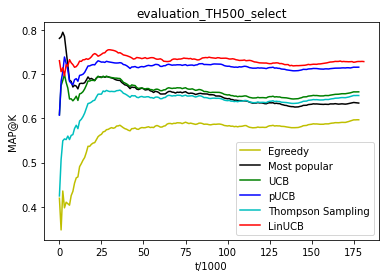

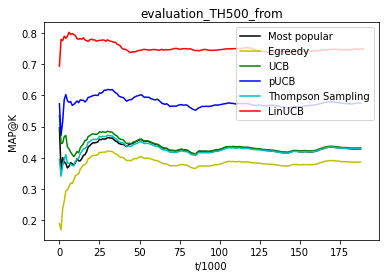

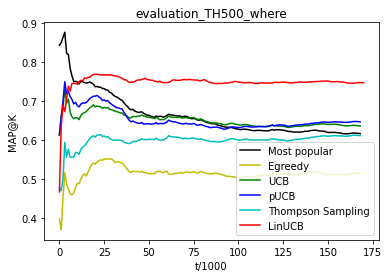

In [2]:
%%time
from sqlcompletions.evaluator import run_n_tests, create_tests
from sqlcompletions.sqlparser import schema



clauses_to_test = [0, 1, 2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [500]

test_names = ["evaluation_TH500_select", "evaluation_TH500_from", "evaluation_TH500_where"]

db = schema()
results = []
for clause in clauses_to_test:
    tests = []
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            tests = create_tests(algorithms=["egreedy","thompson", "ucb", "pucb", "linucb","popular"], clause=clause, top_k = k , db = db , th = th )
    
    results.append(run_n_tests(tests,test_names[clause]).results)

## SELECT Clause

In [3]:
results[0]

,Test,MAP@K,Execution Time
3,pUCB,0.70,0.05
5,LinUCB,0.69,0.66
2,UCB,0.64,0.04
4,Thompson Sampling,0.61,0.07
1,Most popular,0.60,0.04
0,Egreedy,0.57,0.04


## FROM Clause

In [4]:
results[1]

,Test,MAP@K,Execution Time
5,LinUCB,0.70,0.47
3,pUCB,0.57,0.03
0,Most popular,0.45,0.02
2,UCB,0.45,0.02
4,Thompson Sampling,0.44,0.05
1,Egreedy,0.40,0.02


### WHERE Clause

In [5]:
results[2]

,Test,MAP@K,Execution Time
5,LinUCB,0.71,0.61
3,pUCB,0.62,0.06
2,UCB,0.58,0.04
0,Most popular,0.56,0.04
4,Thompson Sampling,0.54,0.08
1,Egreedy,0.48,0.04
